# Test Contrast curves

From two sets of phase screens, with out without predictive AO, generate images and contrast curves.

Use `applefy` library: https://applefy.readthedocs.io/en/latest/

In [5]:
from hcipy import *

#from astropy.modeling import models, fitting

import pynpoint

import pandas as pd
import importlib
import functions
importlib.reload(functions)
from functions import *

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os
#import seaborn as sns


from pathlib import Path
root_dir = Path(".")
print(root_dir)

import applefy
importlib.reload(applefy)
from applefy import *

importlib.reload(applefy.detections.contrast)
from applefy.detections.contrast import Contrast
from applefy.utils.photometry import AperturePhotometryMode
from applefy.statistics import TTest, gaussian_sigma_2_fpf, \
    fpf_2_gaussian_sigma, LaplaceBootstrapTest

from applefy.utils.file_handling import load_adi_data
from applefy.utils import flux_ratio2mag, mag2flux_ratio



.


## Upload and Check phase screens

They are 160x 160 pixels (to save memory). You can either do your focal plane on this dimension of interpolate the phase screens to 256. 
 
For now, it is only 500 frames for each predictive control and integrator. 
 
so with 10x (compared to AO loop) slower science camera they produce 50 images for both control methods.
 
The physical size of the turbulence is 8.53 meters so you can use your own pupil shape and the units of the phase is in micro meters
 

 1.6 um

In [2]:
file_path_int = Path('data/simple_dataset/integrator')
file_path_pred = Path('data/simple_dataset/predictive')

# OPTION 1: Mask outside a range
#integrator  = np.concatenate([arr[np.max(np.abs(arr), axis=(1, 2)) < 1.6] for f in sorted(file_path_int.glob('*.npy')) for arr in [np.load(f)]], axis=0) 
#predictive = np.concatenate([arr[np.max(np.abs(arr), axis=(1, 2)) < 1.6] for f in sorted(file_path_pred.glob('*.npy')) for arr in [np.load(f)]], axis=0) 

# OPTION 2: Mask out the first 100
integrator  = np.concatenate([np.load(f)[100:] for f in sorted(file_path_int.glob('*.npy'))], axis=0) 
predictive  = np.concatenate([np.load(f)[100:] for f in sorted(file_path_pred.glob('*.npy'))], axis=0) 

np.shape(integrator)

#convert to meters
#integrator_ = integrator * 1e-6
#print(integrator[0,35:40,35:40])
#print('---------')
#print(integrator_[0,35:40,35:40])

integrator = integrator  * 1e-6
predictive = predictive * 1e-6

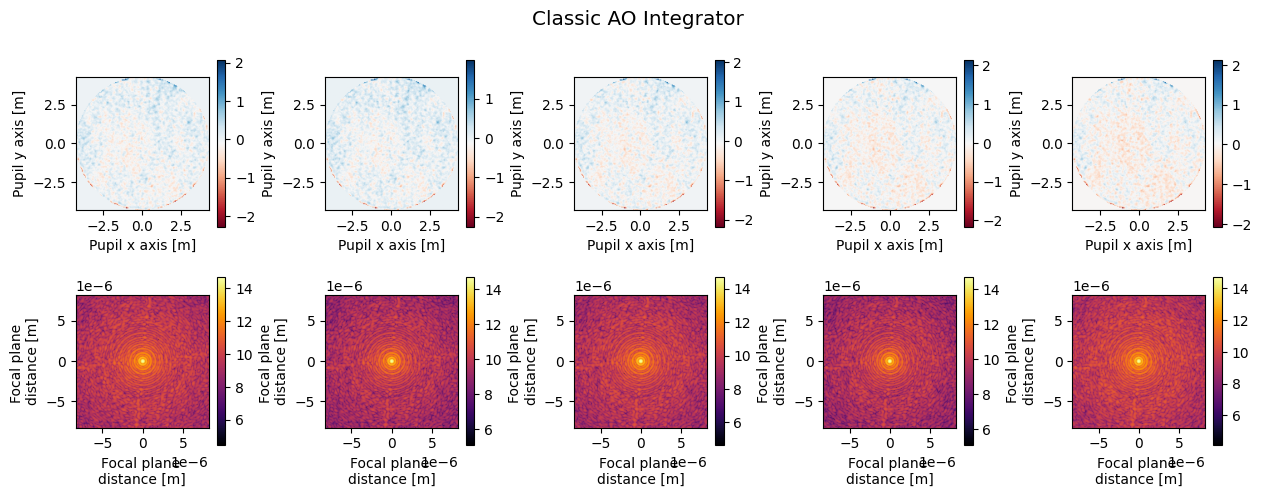

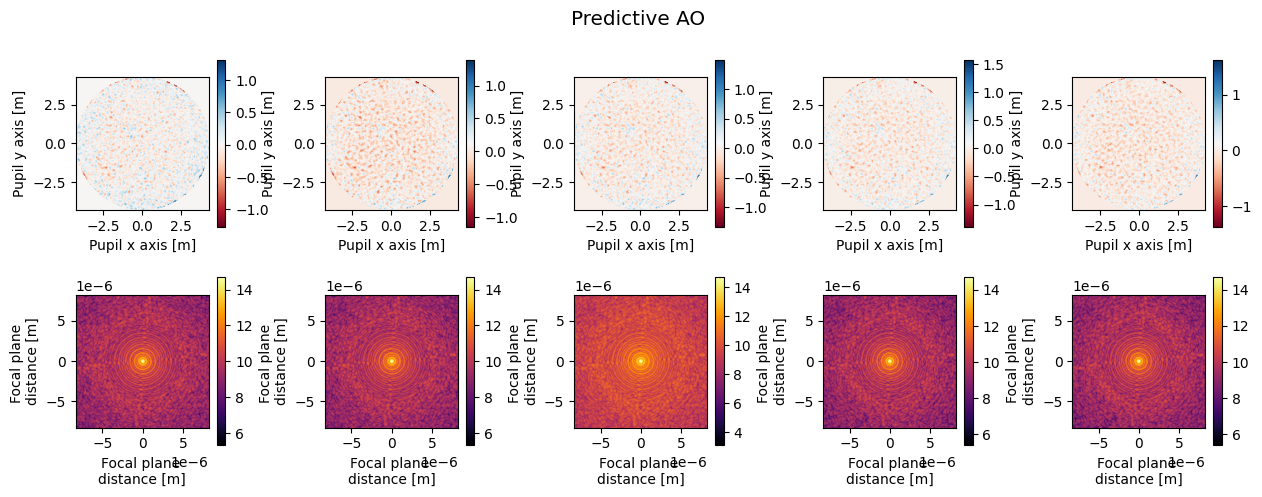

In [ ]:
# VIEW PHASE SCREENS
wavelength_sci = 2.2e-6
oversizing_factor = 16 / 15
num_pupil_pixels = 160 #240 * oversizing_factor
pupil_diameter = 8 # m
pupil_grid_diameter = pupil_diameter * oversizing_factor

q = 4 #number of pixels per diffraction width, 
num_airy = 30 #half size (ie. radius) of the image in the number of diffraction widths.

telescope_pupil, pupil_grid, propagator = generate_focal_plane(wavelength_sci, pupil_diameter, num_pupil_pixels, pupil_grid_diameter, q, num_airy)

aberrated_wf = Wavefront(telescope_pupil, wavelength_sci)  

def view_phase_screens(folder, title, figsize=(15,5),  num = 5):

    plt.figure(figsize=figsize)
    for i in range(0,num):
        plt.subplot(2,(num),i+1)
        ncpa_surface = phase2apodizer(folder[i], telescope_pupil, pupil_grid)
        imshow_field((ncpa_surface.phase(wavelength_sci)), cmap='RdBu')
        plt.colorbar()
        plt.xlabel('Pupil x axis [m]')
        plt.ylabel('Pupil y axis [m]')

        plt.subplot(2,num,i+num+1)
        img = propagator(ncpa_surface(aberrated_wf)).intensity
        imshow_field(np.log10(img), cmap = 'inferno')
        plt.colorbar()
        plt.xlabel('Focal plane \ndistance [m]')
        plt.ylabel('Focal plane \ndistance [m]')

    plt.suptitle(title, fontsize='x-large')
    plt.subplots_adjust(hspace=0.3, wspace = 0.5)
    plt.show()

view_phase_screens(integrator, 'Classic AO Integrator')   
view_phase_screens(predictive, 'Predictive AO') 

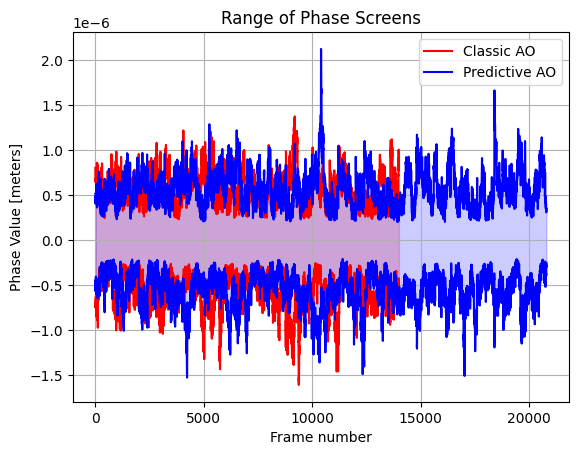

In [5]:
# CHECK THE MASK
plt.plot(range(np.shape(integrator)[0]), np.max(integrator, axis = (1,2)), label = f'Classic AO', color = 'red')
plt.plot(range(np.shape(integrator)[0]), np.min(integrator, axis = (1,2)), color = 'red')
plt.plot(range(np.shape(predictive)[0]), np.max(predictive, axis = (1,2)), label = f'Predictive AO', color = 'blue')
plt.plot(range(np.shape(predictive)[0]), np.min(predictive, axis = (1,2)), color = 'blue')
plt.legend()
plt.fill_between(range(np.shape(integrator)[0]), np.min(integrator, axis = (1,2)), np.max(integrator, axis = (1,2)), color = 'red', alpha=0.2)
plt.fill_between(range(np.shape(predictive)[0]), np.min(predictive, axis = (1,2)), np.max(predictive, axis = (1,2)), color = 'blue', alpha=0.2)
plt.title('Range of Phase Screens')
plt.xlabel('Frame number')
plt.ylabel('Phase Value [meters]')
plt.grid()

## Create and Check Integrated Frames

In [4]:
#all the constants:
contrast            = 3e-4
angular_separation  = 1         # lambda / D
stellar_magnitude   = 3
frame_rate          = 0.001     # AO loop rate in sec
zero_magnitude_flux = 1.7e10    # photon/s VLT value (from Jalo)
charge              = 4
ptv                 = 1e-6

wavelength_sci      = 2.2e-6
oversizing_factor   = 16 / 15
num_pupil_pixels    = 160 #240 * oversizing_factor
pupil_diameter      = 8 # m
pupil_grid_diameter = pupil_diameter * oversizing_factor

q                   = 4 #number of pixels per diffraction width, 
num_airy            = 30 #half size (ie. radius) of the image in the number of diffraction widths.
rad_to_arcsec       = 206265
pixel_size          = wavelength_sci / pupil_diameter / q * rad_to_arcsec  

#------- 
# TO FILL
exposure_time       = 0.01          #s == 50 frames
initial_pa          = 0             # initial angle in degrees
n                   = 14000         #number of phase screens to use
delta_angle         = 0.5           #increment of parraletic angle in DEGREES
n_stat              = 200           #number of phase screens for image statistics
coro_type           = 'vecvortex'   # 'perfect' 'vecvortex' 
#--------

parang              = np.arange(0, (n-0.5)*np.deg2rad(delta_angle)+ initial_pa, np.deg2rad(delta_angle)) #paralletic angles
n_steps             = round(exposure_time / frame_rate) # Number of subframes to integrate

transforms = [ 
    lambda x: x, # original 
    lambda x: np.rot90(x, 1),   # 90° 
    lambda x: np.rot90(x, 2),   # 180° 
    lambda x: np.rot90(x, 3),   # 270° 
    lambda x: np.fliplr(x),     # horizontal flip 
    lambda x: np.flipud(x),     # vertical flip 
    lambda x: x.T,              # main diagonal reflection 
    lambda x: np.rot90(x.T, 2), # anti-diagonal reflection 
] 

#----------------------
telescope_pupil, pupil_grid, propagator = generate_focal_plane(wavelength_sci, pupil_diameter, num_pupil_pixels, pupil_grid_diameter, q, num_airy)


# Cache partially-fixed arguments
common_args = (
    telescope_pupil, 
    propagator,
    pupil_grid_diameter, 
    pupil_grid,
    wavelength_sci,
)

# Create wavefronts
star                = create_wavefront(telescope_pupil, pupil_grid, wavelength_sci, stellar_magnitude = stellar_magnitude, zero_magnitude_flux = zero_magnitude_flux, frame_rate = frame_rate)
planet              = create_wavefront(telescope_pupil, pupil_grid, wavelength_sci, stellar_magnitude = stellar_magnitude, zero_magnitude_flux = zero_magnitude_flux, frame_rate = frame_rate, 
                                        angular_separation= angular_separation, position_angle = initial_pa, contrast= contrast)
off_centred_psf     = create_wavefront(telescope_pupil, pupil_grid, wavelength_sci, stellar_magnitude = stellar_magnitude, zero_magnitude_flux = zero_magnitude_flux, frame_rate = frame_rate,
                                        angular_separation= angular_separation)

# Create reference unaberrated centred PSF and science image
Science_img_perfect = n      * generate_aberrated_frames( *common_args, [star, planet])
unaberrated_PSF     = n_stat * generate_aberrated_frames( *common_args, star) 

In the next cell, I create images off of 100 phase screens each, with predictive and classic AO.

I create:
 - PSF template: off centred coronographic images of the star
 - raw PSF: central star non coronographic for raw contrast calculations
 - science images: aberrated coronographic 


In [4]:
# LONG CELL TO RUN

# Initialize arrays
science_img             = np.zeros_like(Science_img_perfect)
mean_psf_stat_int       = science_img.copy()
mean_psf_stat_pred      = science_img.copy()
mean_psf_stat_int_coro  = science_img.copy()
mean_psf_stat_pred_coro = science_img.copy()
mean_psf_template_int   = science_img.copy()
mean_psf_template_pred  = science_img.copy()
sc_img_frames_int = []
sc_img_frames_pred = []
transform = transforms[0]


if      coro_type == 'perfect':
        perfect_coro    = PerfectCoronagraph(telescope_pupil, charge)
        coro            = perfect_coro
elif    coro_type == 'vecvortex':
        # lyot stop pupil (a little smaller)
        #lyot_stop       = Apodizer(vlt_lyot_stop(pupil_grid))
        #VecVortex       = VectorVortexCoronagraph(charge)
        #coro            = chain(VecVortex, lyot_stop)
        coro            = VectorVortexCoronagraph(charge,vlt_lyot_stop(pupil_grid, Lyot_ratio=1.15, spider_ratio= 5, outer_ratio= 1/0.95))

else:
        warnings.warn("Give a Coronograph type, 'perfect', or 'vecvortex' ")


for i,inte in enumerate(integrator[:n]):
        #planet_wf = create_wavefront(telescope_pupil, pupil_grid, wavelength_sci, stellar_magnitude = stellar_magnitude, zero_magnitude_flux = zero_magnitude_flux, frame_rate = frame_rate, 
         #                               angular_separation= angular_separation, position_angle = (initial_pa+ parang[i]), contrast= contrast)
        integ = transform(inte)
        phase = phase2apodizer(integ, telescope_pupil, pupil_grid)
        if i < n_stat:
                psf                     = (phase(star))
                mean_psf_stat_int       += propagator.forward(psf).power  
                psf_coro                = coro(psf)
                mean_psf_stat_int_coro  += propagator.forward(psf_coro).power  
                mean_psf_template_int   += propagator.forward(coro(phase(off_centred_psf))).power       
        science_img                     += propagator.forward(coro(phase(star))).power #+ propagator.forward(lyot_stop(VecVortex(phase(planet_wf)))).power
        if (i+1)%n_steps == 0:
                sc_img_frames_int.append(science_img.copy())
                science_img.fill(0)
                #transform = transforms[np.random.randint(0,len(transforms))]

science_img.fill(0)

for i,pred in enumerate(predictive[:n]):
        #planet_wf = create_wavefront(telescope_pupil, pupil_grid, wavelength_sci, stellar_magnitude = stellar_magnitude, zero_magnitude_flux = zero_magnitude_flux, frame_rate = frame_rate, 
         #                               angular_separation= angular_separation, position_angle = (initial_pa+ parang[i]), contrast= contrast)
        predi = transform(pred)
        phase = phase2apodizer(predi, telescope_pupil, pupil_grid)
        if i < n_stat:
                psf                     = (phase(star))
                mean_psf_stat_pred      += propagator.forward(psf).power  
                psf_coro                = coro(psf)
                mean_psf_stat_pred_coro += propagator.forward(psf_coro).power  
                mean_psf_template_pred  += propagator.forward(coro(phase(off_centred_psf))).power       
        science_img                     += propagator.forward(coro(phase(star))).power #+ propagator.forward(lyot_stop(VecVortex(phase(planet_wf)))).power
        if (i+1)%n_steps == 0:
                sc_img_frames_pred.append(science_img.copy())
                science_img.fill(0)
                #transform = transforms[np.random.randint(0,len(transforms))]


Text(0.5, 0.98, 'Mean Scientific Image')

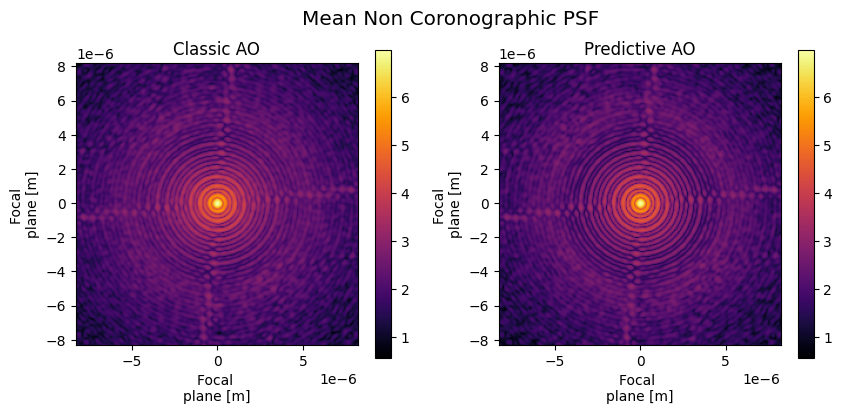

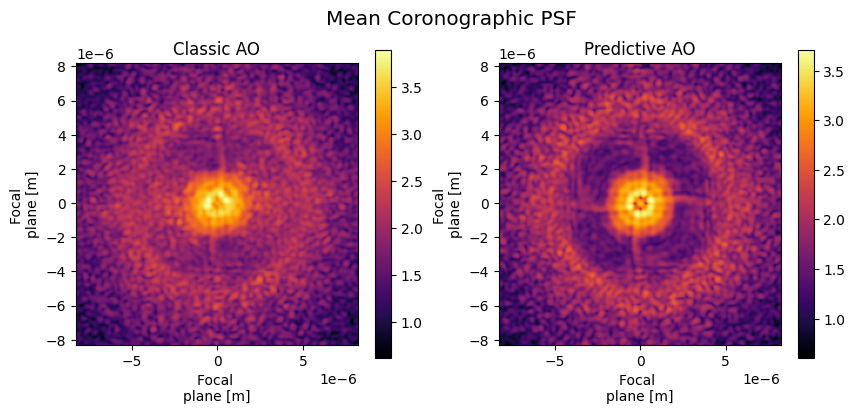

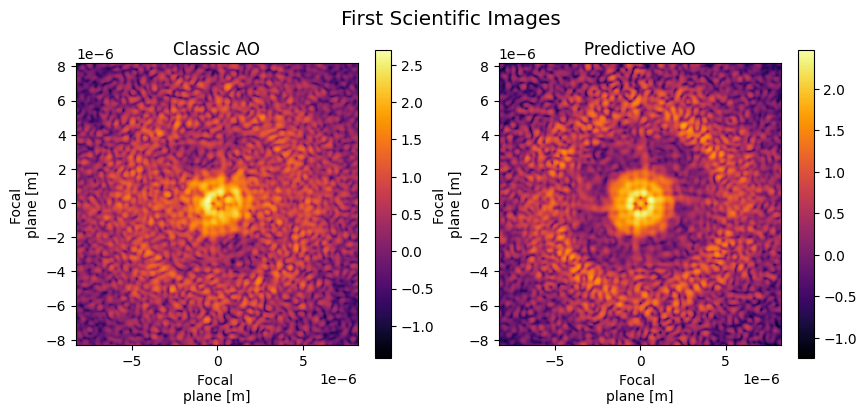

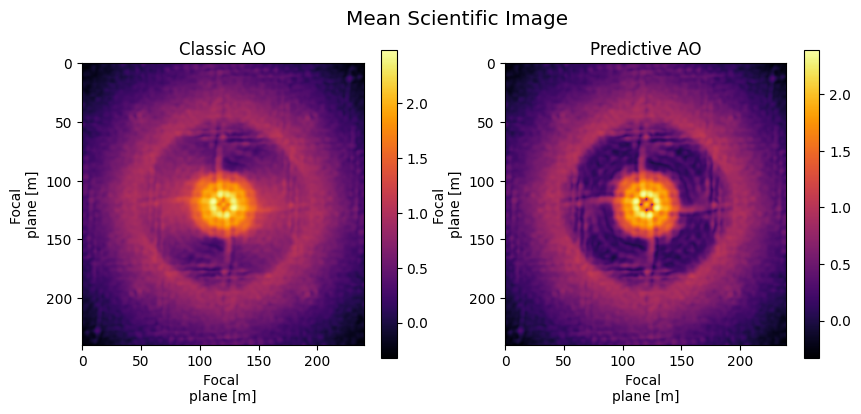

In [106]:
# INSPECTION OF THE FRAMES

plt.figure(figsize=(10,4))

plt.subplot(1, 2, 1)
imshow_field(np.log10(mean_psf_stat_int), cmap='inferno')
plt.colorbar()
plt.xlabel('Focal \nplane [m]')
plt.ylabel('Focal \nplane [m]')
plt.title('Classic AO')
plt.subplot(1, 2, 2)
imshow_field(np.log10(mean_psf_stat_pred), cmap='inferno')
plt.colorbar()
plt.xlabel('Focal \nplane [m]')
plt.ylabel('Focal \nplane [m]')
plt.title('Predictive AO')
plt.suptitle(f'Mean Non Coronographic PSF', fontsize='x-large')

plt.figure(figsize=(10,4))
plt.subplot(1, 2, 1)
imshow_field(np.log10(mean_psf_stat_int_coro), cmap='inferno')
plt.colorbar()
plt.xlabel('Focal \nplane [m]')
plt.ylabel('Focal \nplane [m]')
plt.title('Classic AO')
plt.subplot(1, 2, 2)
imshow_field(np.log10(mean_psf_stat_pred_coro), cmap='inferno')
plt.colorbar()
plt.xlabel('Focal \nplane [m]')
plt.ylabel('Focal \nplane [m]')
plt.title('Predictive AO')
plt.suptitle(f'Mean Coronographic PSF', fontsize='x-large')

plt.figure(figsize=(10,4))
plt.subplot(1, 2, 1)
imshow_field(np.log10(sc_img_frames_int[0]), cmap='inferno')
plt.colorbar()
plt.xlabel('Focal \nplane [m]')
plt.ylabel('Focal \nplane [m]')
plt.title('Classic AO')
plt.subplot(1, 2, 2)
imshow_field(np.log10(sc_img_frames_pred[0]), cmap='inferno')
plt.colorbar()
plt.xlabel('Focal \nplane [m]')
plt.ylabel('Focal \nplane [m]')
plt.title('Predictive AO')
plt.suptitle(f'First Scientific Images', fontsize='x-large')


plt.figure(figsize=(10,4))

mean_frame_int    = np.mean(np.array(sc_img_frames_int).reshape(-1, 240, 240), axis = 0)
mean_frame_pred   = np.mean(np.array(sc_img_frames_pred).reshape(-1, 240, 240), axis = 0)
plt.subplot(1, 2, 1)
plt.imshow(np.log10(mean_frame_int), cmap='inferno')
plt.colorbar()
plt.xlabel('Focal \nplane [m]')
plt.ylabel('Focal \nplane [m]')
plt.title('Classic AO')
plt.subplot(1, 2, 2)
plt.imshow(np.log10(mean_frame_pred), cmap='inferno')
plt.colorbar()
plt.xlabel('Focal \nplane [m]')
plt.ylabel('Focal \nplane [m]')
plt.title('Predictive AO')
plt.suptitle(f'Mean Scientific Image', fontsize='x-large')



Text(0.5, 0.98, 'Mean Scientific Image')

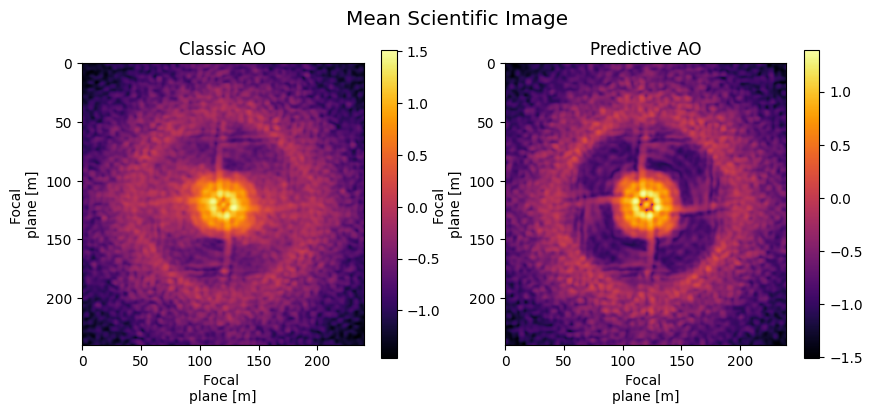

In [54]:
#ONLY CREATE MEAN SCIENCE IMAGES
coro            = VectorVortexCoronagraph(charge,vlt_lyot_stop(pupil_grid, Lyot_ratio=1.15, spider_ratio= 5, outer_ratio= 1/0.95))
mean_int = np.zeros_like(Science_img_perfect)
mean_pred = np.zeros_like(Science_img_perfect)

obs_time = 1000 #ms
for inte in (integrator[:obs_time]):
        phase = phase2apodizer(inte, telescope_pupil, pupil_grid)
        mean_int                     += propagator.forward(coro(phase(star))).power / obs_time#+ propagator.forward(lyot_stop(VecVortex(phase(planet_wf)))).power
for pred in (predictive[:obs_time]):
        phase = phase2apodizer(pred, telescope_pupil, pupil_grid)
        mean_pred                     += propagator.forward(coro(phase(star))).power / obs_time#+ propagator.forward(lyot_stop(VecVortex(phase(planet_wf)))).power

plt.figure(figsize=(10,4))

plt.subplot(1, 2, 1)
plt.imshow(np.log10(np.array(mean_int).reshape(240, 240)), cmap='inferno')
plt.colorbar()
plt.xlabel('Focal \nplane [m]')
plt.ylabel('Focal \nplane [m]')
plt.title('Classic AO')
plt.subplot(1, 2, 2)
plt.imshow(np.log10(np.array(mean_pred).reshape(240, 240)), cmap='inferno')
plt.colorbar()
plt.xlabel('Focal \nplane [m]')
plt.ylabel('Focal \nplane [m]')
plt.title('Predictive AO')
plt.suptitle(f'Mean Scientific Image', fontsize='x-large')

Text(0.5, 0.98, 'Science Frame Diversity (std)')

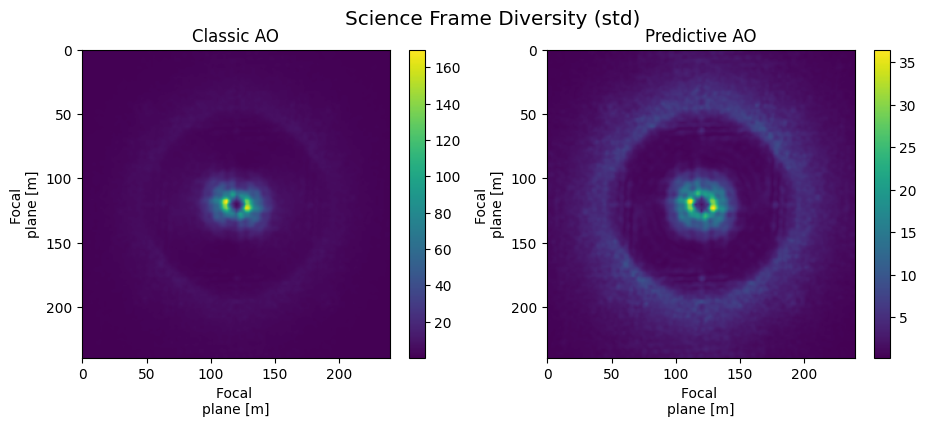

In [107]:
# CHECK SPECKLE DIVERSITY

diff_int  = np.array(sc_img_frames_int).reshape(-1, 240, 240)  - mean_frame_int
diff_pred = np.array(sc_img_frames_pred).reshape(-1, 240, 240) - mean_frame_pred

plt.figure(figsize=(11,4))
plt.subplot(1, 2, 1)
plt.imshow((np.std(diff_int, axis = 0)))
plt.colorbar()
plt.xlabel('Focal \nplane [m]')
plt.ylabel('Focal \nplane [m]')
plt.title('Classic AO')

plt.subplot(1, 2, 2)
plt.imshow((np.std(diff_pred, axis = 0)))
plt.colorbar()
plt.xlabel('Focal \nplane [m]')
plt.ylabel('Focal \nplane [m]')
plt.title('Predictive AO')

plt.suptitle(f'Science Frame Diversity (std)', fontsize='x-large')

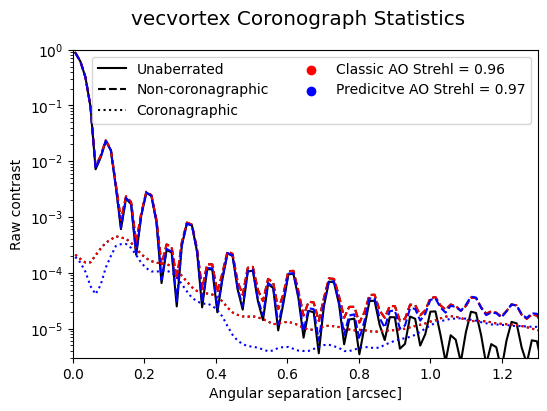

In [5]:
# RAW CONTRAST  AND STREHL(use centred non-coronographic PSF)
rad_to_arcsec       = 206265
spatial_resolution  = wavelength_sci / pupil_diameter
_, y_unaber, _, _   = radial_profile(unaberrated_PSF / unaberrated_PSF.max(), 0.25 * spatial_resolution)

plt.figure(figsize=(6,4))
for i in range(2):
    long_exposure       = mean_psf_stat_int if i ==0 else mean_psf_stat_pred
    long_exposure_coro  = mean_psf_stat_int_coro if i ==0 else mean_psf_stat_pred_coro
    strehl              = get_strehl_from_focal(long_exposure, unaberrated_PSF)
    color               = 'red' if i ==0 else 'blue'
    label               = 'Classic AO' if i==0 else 'Predicitve AO' 
    r, y_coro, yerr, _  = radial_profile(long_exposure_coro / long_exposure.max(), 0.25 * spatial_resolution)
    _, y_noncoro, _, _  = radial_profile(long_exposure / long_exposure.max(), 0.25 * spatial_resolution)
    if i ==0:
        plt.plot(r * rad_to_arcsec, y_unaber, label='Unaberrated', color = 'black')
        plt.plot(r * rad_to_arcsec, y_noncoro, '--',  label='Non-coronagraphic', color = 'black')
        plt.plot(r * rad_to_arcsec, y_coro,':', label='Coronagraphic', color = 'black')        
    plt.plot(r * rad_to_arcsec, y_noncoro, '--', color = color)
    plt.plot(r * rad_to_arcsec, y_coro, ':', color = color)
    plt.scatter(0, 0, marker = 'o', color = color, label = (label + f' Strehl = {float(strehl):.2f}'))
plt.scatter(0, 0,  marker = 'o', color = 'white')
plt.yscale('log')
plt.xlim(0, 1.3)
plt.ylim(3e-6, 1)
plt.xlabel('Angular separation [arcsec]')
plt.ylabel('Raw contrast')

plt.suptitle(f'{coro_type} Coronograph Statistics', fontsize='x-large')

plt.legend(ncols = 2)
plt.savefig('ContrastCurves_test')

## Generate Contrast Curves

In general we need three data arrays to compute contrast curves:

- The science sequence: A 3D array with dimensions (time, x, y)
- A list of parallactic angles for Angular Differential Imaging (time)
- A 2D PSF-template which is used to insert artificial planets and determine the throughput.

### Create the frames

(31, 31)


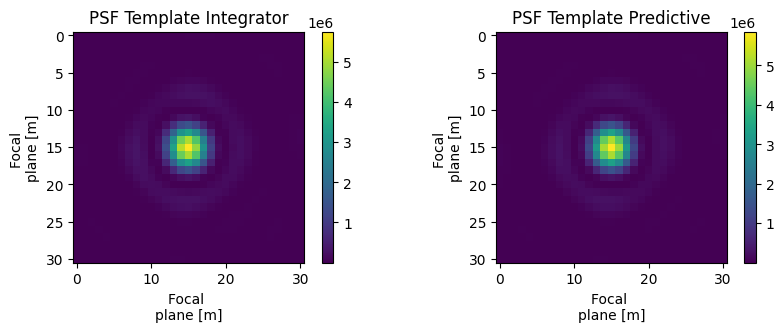

In [6]:
# CENTER THE PSF AROUND MAXIMUM POINT
def zoom_to_peak(img, radius):
    coords_maxpsf = (np.unravel_index(np.argmax(img, axis=None), img.shape))
    img = img[coords_maxpsf[0]-radius:coords_maxpsf[0]+radius+1, coords_maxpsf[1]-radius:coords_maxpsf[1]+radius+1]
    return img


radius = 15
psf_int = zoom_to_peak(mean_psf_template_int.reshape(240,240), radius)
psf_pred = zoom_to_peak(mean_psf_template_pred.reshape(240,240), radius)

print((psf_pred.shape))

plt.figure(figsize=(10,3))
plt.subplot(1, 2, 1)
plt.imshow(psf_int)
plt.colorbar()
plt.xlabel('Focal \nplane [m]')
plt.ylabel('Focal \nplane [m]')
plt.title('PSF Template Integrator')

plt.subplot(1, 2, 2)
plt.imshow(psf_pred)
plt.colorbar()
plt.xlabel('Focal \nplane [m]')
plt.ylabel('Focal \nplane [m]')
plt.title('PSF Template Predictive')
plt.show()

In [7]:
# SAVE THE IMAGES
# the science images should have a format (t, x, y) while the psf is (x,y)
sc_img_int  = np.array(sc_img_frames_int).reshape(-1, 240, 240)
sc_img_pred = np.array(sc_img_frames_pred).reshape(-1, 240, 240)

#name = 'newlyot_large_'
#np.save(f'results/datasets/{name}psf_int.npy', psf_int)
#np.save(f'results/datasets/{name}psf_pred.npy', psf_pred)
#np.save(f'results/datasets/{name}sc_img_int.npy', sc_img_int)
#np.save(f'results/datasets/{name}sc_img_pred.npy', sc_img_pred)

In [30]:
name = 'vecvortex_'
os.remove(f'results/datasets/{name}psf_int.npy')
os.remove(f'results/datasets/{name}psf_pred.npy')
os.remove(f'results/datasets/{name}sc_img_int.npy')
os.remove(f'results/datasets/{name}sc_img_pred.npy')

### Load frames

In [3]:
name = 'perfect_large_' #'vecvortex_large_' #'transform_'
psf_int     = np.load(f'results/datasets/{name}psf_int.npy')
psf_pred    = np.load(f'results/datasets/{name}psf_pred.npy')
sc_img_int  = np.load(f'results/datasets/{name}sc_img_int.npy')
sc_img_pred = np.load(f'results/datasets/{name}sc_img_pred.npy')

Text(0.5, 0.98, 'Mean Scientific Image')

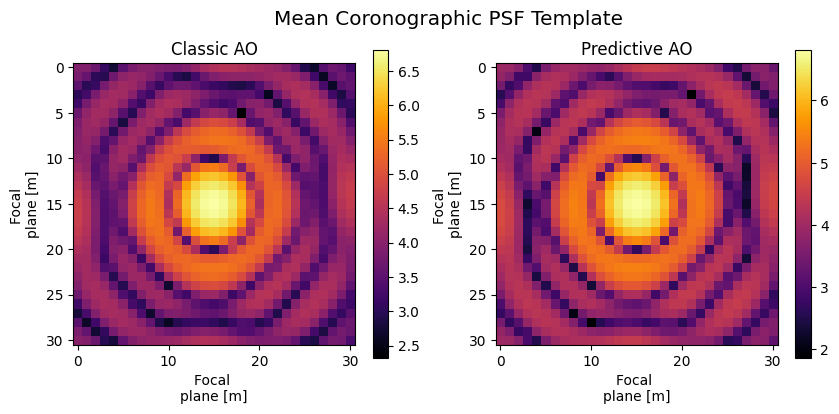

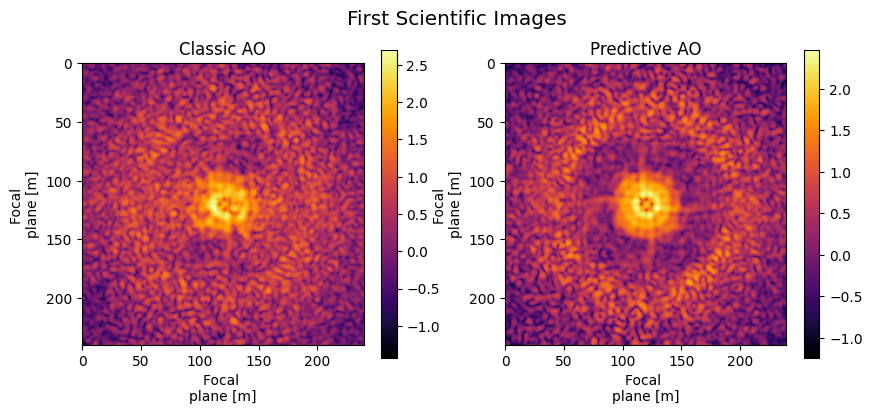

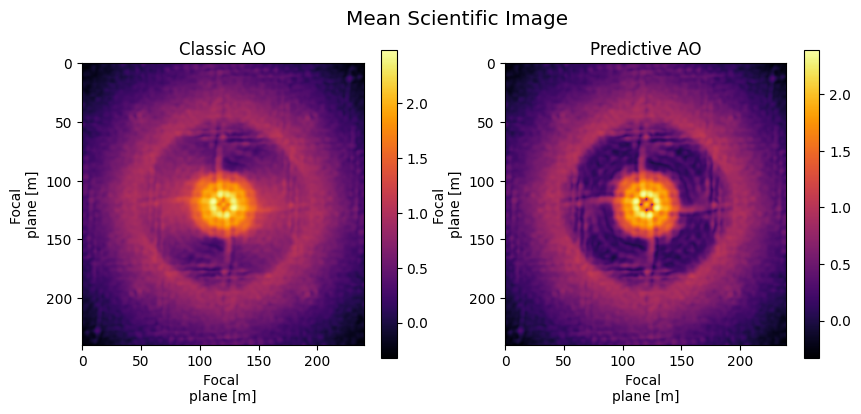

In [ ]:
# QUICK LOOK

plt.figure(figsize=(10,4))
plt.subplot(1, 2, 1)
plt.imshow(np.log10(psf_int), cmap='inferno')
plt.colorbar()
plt.xlabel('Focal \nplane [m]')
plt.ylabel('Focal \nplane [m]')
plt.title('Classic AO')
plt.subplot(1, 2, 2)
plt.imshow(np.log10(psf_pred), cmap='inferno')
plt.colorbar()
plt.xlabel('Focal \nplane [m]')
plt.ylabel('Focal \nplane [m]')
plt.title('Predictive AO')
plt.suptitle(f'Mean Coronographic PSF Template', fontsize='x-large')

plt.figure(figsize=(10,4))
plt.subplot(1, 2, 1)
plt.imshow(np.log10(sc_img_int[0]), cmap='inferno')
plt.colorbar()
plt.xlabel('Focal \nplane [m]')
plt.ylabel('Focal \nplane [m]')
plt.title('Classic AO')
plt.subplot(1, 2, 2)
plt.imshow(np.log10(sc_img_pred[0]), cmap='inferno')
plt.colorbar()
plt.xlabel('Focal \nplane [m]')
plt.ylabel('Focal \nplane [m]')
plt.title('Predictive AO')
plt.suptitle(f'First Scientific Images', fontsize='x-large')


plt.figure(figsize=(10,4))
plt.subplot(1, 2, 1)
plt.imshow(np.log10(np.mean(sc_img_int, axis = 0)), cmap='inferno')
plt.colorbar()
plt.xlabel('Focal \nplane [m]')
plt.ylabel('Focal \nplane [m]')
plt.title('Classic AO')
plt.subplot(1, 2, 2)
plt.imshow(np.log10(np.mean(sc_img_pred, axis = 0)), cmap='inferno')
plt.colorbar()
plt.xlabel('Focal \nplane [m]')
plt.ylabel('Focal \nplane [m]')
plt.title('Predictive AO')
plt.suptitle(f'Mean Scientific Image', fontsize='x-large')




### Processing Tutorial

In [ ]:
dataset_config          = {'file_path': Path('/home/aosimul/noah/results/datasets/betapic_naco_lp_LR.hdf5'),
                        'stack_key': "science_no_planet",
                        'psf_template_key': "psf_template",
                        'parang_key': 'header_science_no_planet/PARANG',
                        'dit_psf_template': 0.02019,
                        'fwhm_size' : 4.2, # Diameter in pixel
                        'dit_science': 0.2}

science_data, angles, raw_psf_template_data = load_adi_data(root_dir/dataset_config["file_path"],
                                                            data_tag        =dataset_config["stack_key"],
                                                            psf_template_tag=dataset_config["psf_template_key"],
                                                            para_tag        =dataset_config["parang_key"])

dit_psf_template        = dataset_config["dit_psf_template"]
dit_science             = dataset_config["dit_science"]
fwhm                    = dataset_config["fwhm_size"]
psf_template            = raw_psf_template_data[82:-82, 82:-82]

# fake planet brightness
flux_ratio_mag          =14
num_fake_planets        = 3
components              = [5, 10, 20, 30, 50, 75, 100]

flux_ratio              = mag2flux_ratio(flux_ratio_mag)
print("Brightness of fake planets in mag: " + str(flux_ratio_mag))
print("Planet-to-star flux ratio: " + str(flux_ratio))

output_path = Path("/home/aosimul/noah/results/tutorial/contrast_curves")

import shutil 
if output_path.exists():
    shutil.rmtree(output_path)
    print(f"Removed existing directory to avoid overwrites: {output_path}.")

output_path.mkdir(
    parents=True,
    exist_ok=True
)

contrast_instance_tut = Contrast(
    science_sequence    =science_data,
    psf_template        =psf_template,
    parang_rad          =angles,
    psf_fwhm_radius     =fwhm / 2,
    dit_psf_template    =dit_psf_template,
    dit_science         =dit_science,
    scaling_factor      =1., # A factor to account e.g. for ND filters
    checkpoint_dir      = output_path)

contrast_instance_tut = fake_planet_experiment(contrast_instance_tut, flux_ratio, num_fake_planets, components)
contrast_curves_tut, contrast_errors_tut = compute_contrast_curves(contrast_instance_tut, fwhm, pixel_scale=0.02, photometry = 'FS', test = 't-test')

Brightness of fake planets in mag: 14
Planet-to-star flux ratio: 2.5118864315095823e-06
Removed existing directory to avoid overwrites: /home/aosimul/noah/results/tutorial/contrast_curves.
Running fake planet experiments...

 50%|█████     | 32/64 [00:00<00:00, 192.04it/s]/home/aosimul/torch-test/lib64/python3.12/site-packages/fours/utils/pca.py:31: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  images_torch = torch.from_numpy(images).to(device)


[Timing] Convert to tensor: 0.003204s


 50%|█████     | 32/64 [00:11<00:00, 192.04it/s]

Running fake planet experiments...

...

[Timing] PCA Residuals: 2.819747s
allocated: 0.0
reserved: 0.0
[Timing] _run_fake_planet_experiment: 9.673163s
[Timing] Convert to tensor: 0.000051s
[Timing] Compute PCA Basis: 5.136433s
[Timing] Field rotation: 0.033661s
len gc objects: 501014
len gc objects: 500988
len gc objects: 501011
len gc objects: 501012
len gc objects: 500991
len gc objects: 500992
len gc objects: 500993


[Timing] PCA Residuals: 2.752908s
allocated: 0.0
reserved: 0.0
[Timing] _run_fake_planet_experiment: 9.713561s
[Timing] Convert to tensor: 0.000051s
[Timing] Compute PCA Basis: 4.830425s
[Timing] Field rotation: 0.043763s
len gc objects: 501021
len gc objects: 500995
len gc objects: 501018
len gc objects: 501019
len gc objects: 500998
len gc objects: 500999
len gc objects: 501000


[Timing] PCA Residuals: 2.815967s
allocated: 0.0
reserved: 0.0
[Timing] _run_fake_planet_experiment: 9.569515s
[Timing] Convert to tensor: 0.000047s
[Timing] Compute PCA Basis: 5.247698s
[Timing] Field rotation: 0.052960s
len gc objects: 501028
len gc objects: 501002
len gc objects: 501025
len gc objects: 501026
len gc objects: 501005
len gc objects: 501006
len gc objects: 501007


[Timing] PCA Residuals: 2.965261s
allocated: 0.0
reserved: 0.0
[Timing] _run_fake_planet_experiment: 10.135345s
[Timing] Convert to tensor: 0.000051s
[Timing] Compute PCA Basis: 4.835186s
[Timing] Field rotation: 0.043104s
len gc objects: 501035
len gc objects: 501009
len gc objects: 501032
len gc objects: 501011
len gc objects: 501012
len gc objects: 501013
len gc objects: 501014


[Timing] PCA Residuals: 2.319906s
allocated: 0.0
reserved: 0.0
[Timing] _run_fake_planet_experiment: 8.951858s
[Timing] Convert to tensor: 0.000048s
[Timing] Compute PCA Basis: 5.088094s
[Timing] Field rotation: 0.041018s
len gc objects: 501041


/home/aosimul/noah/notebooks/functions.py:572: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap(cmap)   # seaborn-style colormap available in mpl


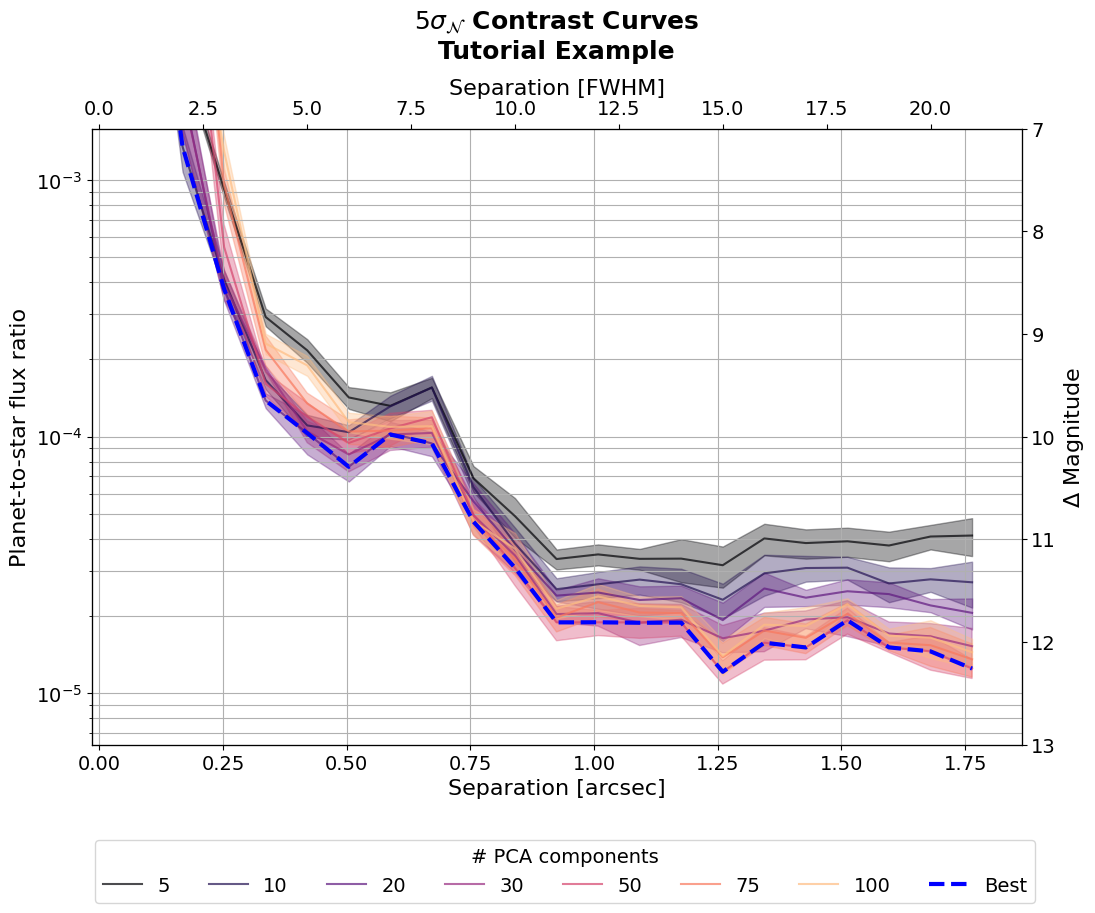

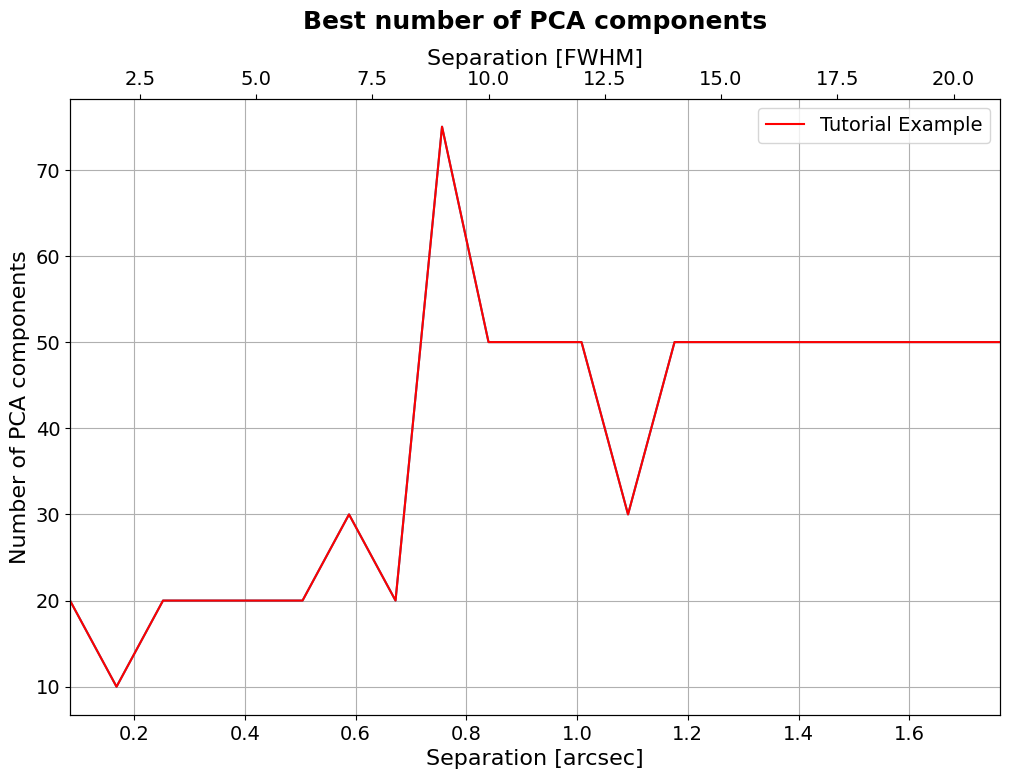

In [4]:
# MAKE PLOTS

plot_contrast_curves(contrast_curves_tut, contrast_errors_tut, (13,7), title =(r"$5 \sigma_{\mathcal{N}}$ Contrast Curves" +"\nTutorial Example"))
plot_best_PCA_number([contrast_curves_tut], components, ['Tutorial Example'])

### Full Post Processing Comparison with the functions

In [ ]:
# CREATE DATASETS
datasets = {
    # "int": {
    #     "psf"           : psf_int,
    #     "sci_img"       : sc_img_int,
    #     "sci_img_odd"   : sc_img_int[:, :-1, :-1],
    #     "fwhm"          : calculate_fwhm(psf_int),
    #     "dit_psf"       : n_stat * frame_rate,      #s of integration time
    #     "dit_science"   : exposure_time,            #s = 10 phase screens at 0.001s each
    # },
    "pred": {
        "psf"           : psf_pred,
        "sci_img"       : sc_img_pred,
        "sci_img_odd"   : sc_img_pred[:, :-1, :-1],
        "fwhm"          : calculate_fwhm(psf_pred),
        "dit_psf"       : n_stat * frame_rate,      #s of integration time
        "dit_science"   : exposure_time,
    },
}

algorithms = {
    "PCAD": "PCAD",
    "CADI": "CADI",
}

curves = {}

#FILL
#-----------
# fake planet brightness
flux_ratio_mag          = 16
num_fake_planets        = 2
components              = [2] 
scaling_factor          = 1.0  # A factor to account e.g. for ND filters
angles                  = np.linspace(0, 30, np.shape(sc_img_int)[0])    #parang[::10]
angles                  = np.deg2rad(angles)
flux_ratio              = mag2flux_ratio(flux_ratio_mag)
name                    = 'perfect'
#-----------

for dataset_name, dataset in datasets.items():
    for algo_name, device in algorithms.items():

        path = f"results/contrast_curves/{name}_{dataset_name}_test"
        if not os.path.exists(path):
            os.makedirs(path)
            
        contrast_instance = Contrast(
            science_sequence    =dataset["sci_img_odd"][:5],
            psf_template        =dataset["psf"],
            parang_rad          =angles[:5],
            psf_fwhm_radius     =dataset["fwhm"] / 2, # Diameter in pixel
            dit_psf_template    =dataset["dit_psf"], 
            dit_science         =dataset["dit_science"],  # integration time
            scaling_factor      =scaling_factor, # A factor to account e.g. for ND filters
            checkpoint_dir      =root_dir / Path(path)
            )

        contrast_instance = fake_planet_experiment(contrast_instance, flux_ratio, num_fake_planets, components, version = device)
        curves[(dataset_name, algo_name)] = compute_contrast_curves(contrast_instance, dataset["fwhm"], pixel_scale=pixel_size,  photometry = 'AS', test = 't-test')


    # save the contrast curves in a single dataframe
    (curve, err) = curves[(dataset_name, "PCAD")]
    (curve_cadi, err_cadi) = curves[(dataset_name, "CADI")]

    curves[(dataset_name, "merged")] = (
        pd.merge(curve, curve_cadi, left_index= True, right_index=True, how="inner"),
        pd.merge(err, err_cadi, left_index= True, right_index=True, how="inner")
    )

FWHM_x = 3.83 pix
FWHM_y = 3.82 pix
Mean FWHM = 3.82 pix 

Running fake planet experiments...

100%|██████████| 63/63 [00:00<00:00, 1369.47it/s]
/home/aosimul/noah/.venv/lib64/python3.12/site-packages/fours/utils/pca.py:22: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  images_torch = torch.from_numpy(images).to(device)


Running fake planet experiments...

 67%|██████▋   | 42/63 [07:42<03:52, 11.07s/it]

In [ ]:
# CREATE CURVES FROM CHECKPOINT DIR

datasets = {
    # "int": {
    #     "psf"           : psf_int,
    #     "sci_img"       : sc_img_int,
    #     "sc_img_odd"    : sc_img_int[:, :-1, :-1],
    #     "fwhm"          : calculate_fwhm(psf_int),
    #     "dit_psf"       : n_stat * frame_rate,      #s of integration time
    #     "dit_science"   : exposure_time,            #s = 10 phase screens at 0.001s each
    # },
    "pred": {
        "psf"           : psf_pred,
     #   "sci_img"       : sc_img_pred,
      #  "sc_img_odd"    : sc_img_pred[:, :-1, :-1],
        "fwhm"          : calculate_fwhm(psf_pred),
        "dit_psf"       : n_stat * frame_rate,      #s of integration time
        "dit_science"   : exposure_time,
    },
}

algorithms = {
    "PCAD": "PCAD",
    "CADI": "CADI",
}

curves = {}

#FILL
#-----------
name                    = 'perfect'
#-----------


for dataset_name, dataset in datasets.items():
    for algo_name, device in algorithms.items():

        path = f"results/contrast_curves/{name}_{dataset_name}_test"
        
        contrast_instance = Contrast.create_from_checkpoint_dir(
            psf_template        =dataset["psf"],
            psf_fwhm_radius     =dataset["fwhm"] / 2, # Diameter in pixel
            dit_psf_template    =dataset["dit_psf"], 
            dit_science         =dataset["dit_science"],  # integration time
            checkpoint_dir      =root_dir / Path(path)
            )

        curves[(dataset_name, algo_name)] = compute_contrast_curves(contrast_instance, dataset["fwhm"], pixel_scale=pixel_size,  photometry = 'AS', test = 't-test')


    # save the contrast curves in a single dataframe
    (curve, err) = curves[(dataset_name, "PCAD")]
    (curve_cadi, err_cadi) = curves[(dataset_name, "CADI")]

    curves[(dataset_name, "merged")] = (
        pd.merge(curve, curve_cadi, left_index= True, right_index=True, how="inner"),
        pd.merge(err, err_cadi, left_index= True, right_index=True, how="inner")
    )

FWHM_x = 3.89 pix
FWHM_y = 4.12 pix
Mean FWHM = 4.00 pix 

FWHM_x = 3.88 pix
FWHM_y = 4.11 pix
Mean FWHM = 4.00 pix 



Computing contrast curve for _PCA_002_components


100%|██████████| 29/29 [00:30<00:00,  1.05s/it]


Computing contrast curve for _PCA_005_components


100%|██████████| 29/29 [00:30<00:00,  1.05s/it]


...

100%|██████████| 29/29 [00:30<00:00,  1.06s/it]


Computing contrast curve for _PCA_015_components


100%|██████████| 29/29 [00:30<00:00,  1.06s/it]


Computing contrast curve for cADI


100%|██████████| 29/29 [00:30<00:00,  1.06s/it]


In [ ]:
#OLD

fwhm_psf_int            = calculate_fwhm(psf_int)
fwhm_psf_pred           = calculate_fwhm(psf_pred)
dit_psf_template_int    = n_stat * frame_rate   #s of integration time
dit_psf_template_pred   = n_stat * frame_rate   #s of integration time
dit_science             = exposure_time         #s = 10 phase screens at 0.001s each


#Make the science images odd
sc_img_int_odd  = sc_img_int[:, :-1, :-1]
sc_img_pred_odd = sc_img_pred[:, :-1, :-1]
psf_int_even    = psf_int[ :-1, :-1]
psf_pred_even   = psf_pred[ :-1, :-1]
#-----------

#FILL
#-----------
# fake planet brightness
flux_ratio_mag          = 16
num_fake_planets        = 4
components              = [2, 5, 10, 15] 
scaling_factor          = 1.0  # A factor to account e.g. for ND filters
angles                  = np.linspace(0, 30, np.shape(sc_img_int)[0])    #parang[::10]
angles                  = np.deg2rad(angles)
flux_ratio              = mag2flux_ratio(flux_ratio_mag)
name                    = 'test'
saving_folders          = [f'{name}_int', f'{name}_int_cADI', f'{name}_pred', f'{name}_pred_cADI']
contrast_curves         = [] 

#-----------


print("Brightness of fake planets in mag: " + str(flux_ratio_mag))
print("Planet-to-star flux ratio: "         + str(flux_ratio))

for i in range(4):
    if i < 2:
        contrast_instance = Contrast(
            science_sequence=sc_img_int_odd,
            psf_template=psf_int,
            parang_rad=angles,
            psf_fwhm_radius=fwhm_psf_int / 2, # Diameter in pixel
            dit_psf_template=dit_psf_template_int, 
            dit_science=dit_science, # integration time
            scaling_factor=scaling_factor, # A factor to account e.g. for ND filters
            checkpoint_dir=root_dir / Path(f"results/contrast_curves/{saving_folders[i]}")
            )
        
    else:
        contrast_instance = (Contrast(
            science_sequence=sc_img_pred_odd,
            psf_template=psf_pred,
            parang_rad= angles,
            psf_fwhm_radius=fwhm_psf_pred / 2, # Diameter in pixel
            dit_psf_template=dit_psf_template_pred, 
            dit_science=dit_science, # integration time
            scaling_factor=scaling_factor, # A factor to account e.g. for ND filters
            checkpoint_dir=root_dir / Path(f"results/contrast_curves/{saving_folders[i]}")
            ))
    
    device = 'CADI' if i%2 ==1 else 'PCAD'
    contrast_instance = fake_planet_experiment(contrast_instance, flux_ratio, num_fake_planets, components, version= device)
    contrast_curves.append(compute_contrast_curves(contrast_instance, fwhm_psf_int, pixel_scale=pixel_size,  photometry = 'AS', test = 't-test'))


FWHM_x = 3.98 pix
FWHM_y = 4.15 pix
Mean FWHM = 4.06 pix 

FWHM_x = 3.97 pix
FWHM_y = 4.15 pix
Mean FWHM = 4.06 pix 

Brightness of fake planets in mag: 16
Planet-to-star flux ratio: 3.981071705534969e-07
Overwriting existing config files.
Running fake planet experiments...

/home/aosimul/noah/.venv/lib64/python3.12/site-packages/fours/utils/adi_tools.py:31: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  images = torch.from_numpy(images).to(device)
100%|██████████| 117/117 [00:45<00:00,  2.58it/s]


[DONE]
Computing contrast curve for cADI


100%|██████████| 29/29 [00:30<00:00,  1.04s/it]


Running fake planet experiments...

/home/aosimul/noah/.venv/lib64/python3.12/site-packages/fours/utils/adi_tools.py:31: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  images = torch.from_numpy(images).to(device)
100%|██████████| 117/117 [00:14<00:00,  8.13it/s]


[DONE]
Computing contrast curve for cADI


100%|██████████| 29/29 [00:30<00:00,  1.04s/it]


In [ ]:
# OLD
# COMPUTE CONTRAST FROM CHECKPOINT DIR

fwhm_psf_int            = calculate_fwhm(psf_int)
fwhm_psf_pred           = calculate_fwhm(psf_pred)
dit_psf_template_int    = n_stat * frame_rate   #s of integration time
dit_psf_template_pred   = n_stat * frame_rate   #s of integration time
dit_science             = exposure_time         #s = 10 phase screens at 0.001s each


#Make the science images odd
sc_img_int_odd  = sc_img_int[:, :-1, :-1]
sc_img_pred_odd = sc_img_pred[:, :-1, :-1]
psf_int_even    = psf_int[ :-1, :-1]
psf_pred_even   = psf_pred[ :-1, :-1]
#-----------

name                    = 'test'
saving_folders          = [f'{name}', f'{name}_CADI', f'{name}2', f'{name}2_CADI']
contrast_curves         = [] 

for i in range(4):
    if i < 2:
        contrast_instance = Contrast.create_from_checkpoint_dir(
            psf_int, 
            fwhm_psf_int / 2,
            dit_science, 
            dit_psf_template_int, 
            root_dir / Path(f"results/contrast_curves/{saving_folders[i]}"))
    else:
        contrast_instance = Contrast.create_from_checkpoint_dir(
            psf_pred, 
            fwhm_psf_pred / 2,
            dit_science, 
            dit_psf_template_pred, 
            root_dir / Path(f"results/contrast_curves/{saving_folders[i]}"))
        
    contrast_curves.append(compute_contrast_curves(contrast_instance, fwhm_psf_int,  pixel_scale=pixel_size, photometry = 'AS', test = 't-test'))



FWHM_x = 3.89 pix
FWHM_y = 4.12 pix
Mean FWHM = 4.00 pix 

FWHM_x = 3.88 pix
FWHM_y = 4.11 pix
Mean FWHM = 4.00 pix 

Computing contrast curve for _PCA_002_components


100%|██████████| 29/29 [00:30<00:00,  1.06s/it]


Computing contrast curve for _PCA_005_components


100%|██████████| 29/29 [00:30<00:00,  1.06s/it]


Computing contrast curve for _PCA_010_components


...

100%|██████████| 29/29 [00:30<00:00,  1.06s/it]


Computing contrast curve for _PCA_015_components


100%|██████████| 29/29 [00:30<00:00,  1.05s/it]


Computing contrast curve for cADI


100%|██████████| 29/29 [00:30<00:00,  1.07s/it]


/home/aosimul/noah/functions.py:499: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap(cmap)   # seaborn-style colormap available in mpl
/home/aosimul/noah/functions.py:499: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap(cmap)   # seaborn-style colormap available in mpl


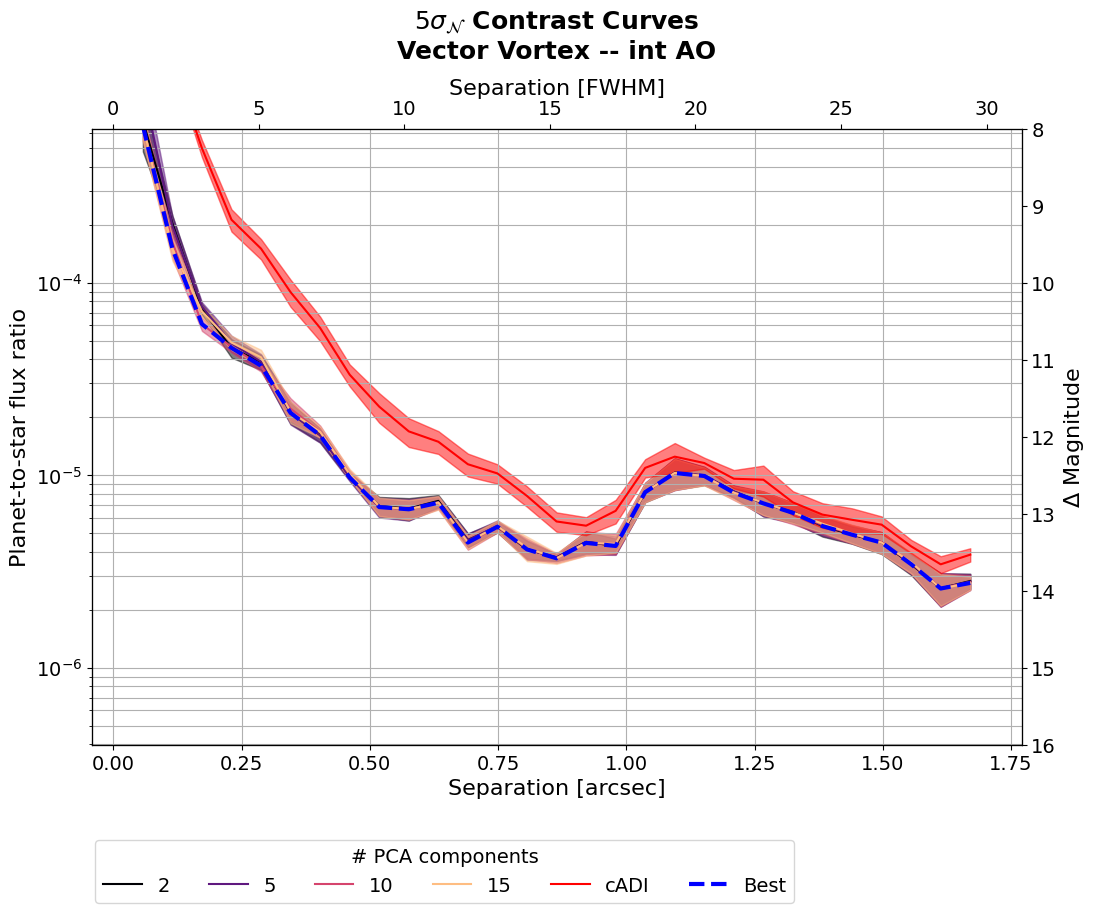

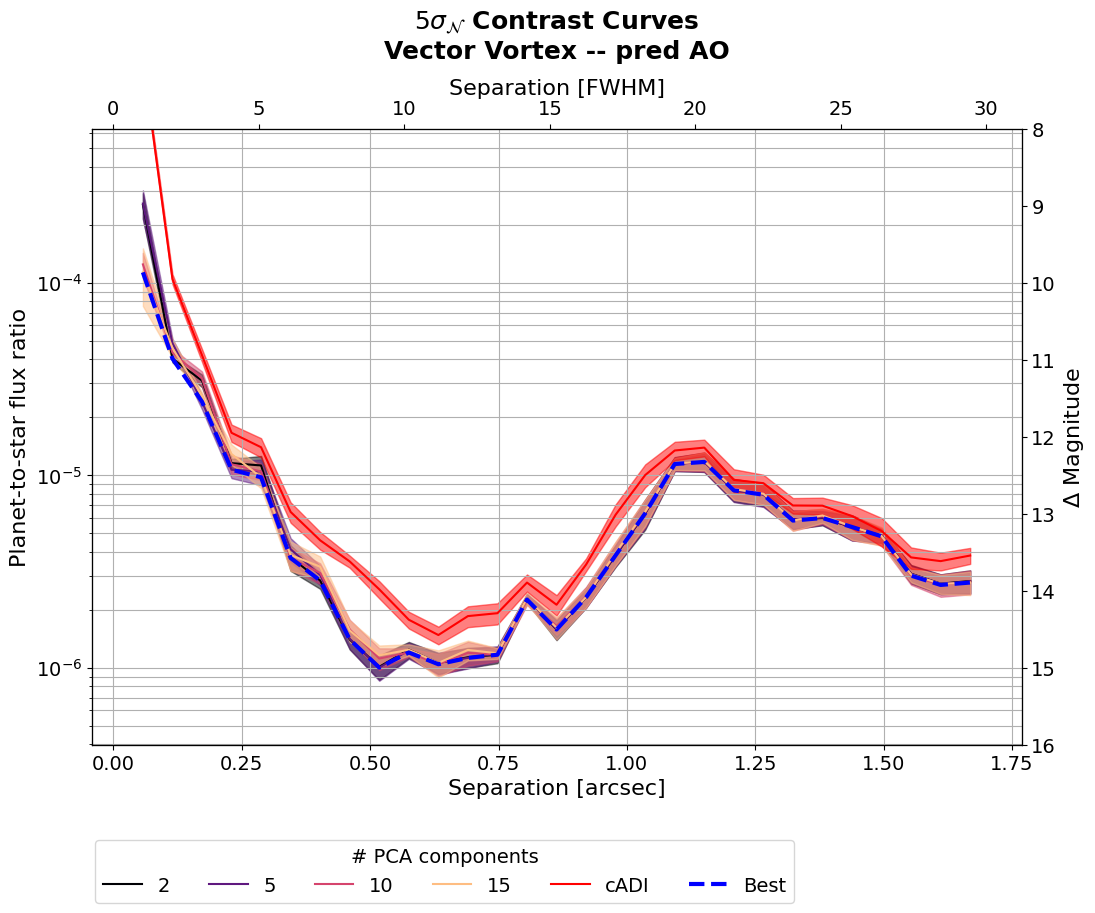

In [7]:
# MAKE PLOTS
rangey = (16, 8)
name = 'Vector Vortex'

for dataset_name, dataset in datasets.items():
    contrast, err = curves[(dataset_name, "merged")]
    plot_contrast_curves(contrast, err, rangey, title =(r"$5 \sigma_{\mathcal{N}}$ Contrast Curves" +f"\n{name} -- {dataset_name} AO"))
    plt.savefig(f'{dataset_name}_{name}.png')

#plot_best_PCA_number([contrast_curves_int, contrast_curves_pred], components, ['Classic AO', 'Predictive AO'])
#plt.savefig(f'PCA_{name}.png')




In [16]:
# VIEW/ANIMATION FAKE PLANET EXPERIMENT

folder = '/home/aosimul/noah/results/contrast_curves/test'
create_pca_gif(
    folder,
    components,
    output_gif="int_newlyot_safe.gif",
    duration=0.5,
)

folder = '/home/aosimul/noah/results/contrast_curves/test2'
create_pca_gif(
    folder,
    components,
    output_gif="pred_newlyot_safe.gif",
    duration=0.5,
)

Saved GIF: int_newlyot_safe.gif
Saved GIF: pred_newlyot_safe.gif


### Stage 1 GHOST

## Lyot Stop

/tmp/ipykernel_896539/1366055029.py:21: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(


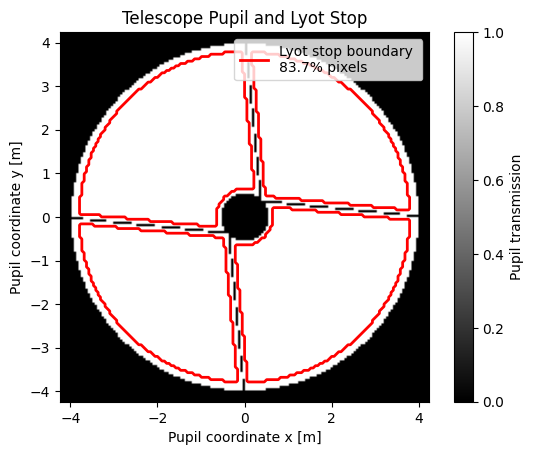

In [48]:
lyot = vlt_lyot_stop(pupil_grid, Lyot_ratio=1.15, spider_ratio= 5, outer_ratio= 1/0.95)

# Coordinates for contour plotting
x = pupil_grid.x.reshape(pupil_grid.shape)
y = pupil_grid.y.reshape(pupil_grid.shape)


# Display pupil
fig, ax = plt.subplots()
im = ax.imshow(
    telescope_pupil.shaped,
    extent=[x.min(), x.max(), y.min(), y.max()],
    origin='lower',
    cmap='gray'
)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Pupil transmission')

# Overlay Lyot stop contour in red
ax.contour(
    x,
    y,
    lyot.shaped,
    levels=[0.5],
    colors='red',
    linewidths=2,
    label = 'Lyot stop boundary'
)

# Legend (proxy artist)
legend_elements = [
    Line2D(
        [0], [0],
        color='red',
        lw=2,
        label=f'Lyot stop boundary \n{100*np.sum(lyot)/np.sum(telescope_pupil):.1f}% pixels'
    )
]

ax.legend(handles=legend_elements, loc='upper right')

ax.set_xlabel('Pupil coordinate x [m]')
ax.set_ylabel('Pupil coordinate y [m]')
ax.set_title('Telescope Pupil and Lyot Stop')
ax.set_aspect('equal')
